# The main goal: To predict the success of a new restaurant in europe based on TripAdvisor data set

##Importing Libraries

In [33]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


## Loading the data

In [34]:
# Load the initial dataset
initial_df = pd.read_csv("../data/raw/tripadvisor_european_restaurants.csv")
initial_df.head()

C:\Users\Psychologist\AppData\Local\Temp\ipykernel_13988\638981460.py:2: DtypeWarning: Columns (0: region) have mixed types. Specify dtype option on import or set low_memory=False.
  initial_df = pd.read_csv("../data/raw/tripadvisor_european_restaurants.csv")


,restaurant_link,restaurant_name,original_location,country,region,province,city,address,latitude,longitude,...,excellent,very_good,average,poor,terrible,food,service,value,atmosphere,keywords
0,g10001637-d10002227,Le 147,"[""Europe"", ""France"", ""Nouvelle-Aquitaine"", ""Ha...",France,Nouvelle-Aquitaine,Haute-Vienne,Saint-Jouvent,"10 Maison Neuve, 87510 Saint-Jouvent France",45.961674,1.169131,...,2.0,0.0,0.0,0.0,0.0,4.0,4.5,4.0,NaN,NaN
1,g10001637-d14975787,Le Saint Jouvent,"[""Europe"", ""France"", ""Nouvelle-Aquitaine"", ""Ha...",France,Nouvelle-Aquitaine,Haute-Vienne,Saint-Jouvent,"16 Place de l Eglise, 87510 Saint-Jouvent France",45.957040,1.205480,...,2.0,2.0,1.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
2,g10002858-d4586832,Au Bout du Pont,"[""Europe"", ""France"", ""Centre-Val de Loire"", ""B...",France,Centre-Val de Loire,Berry,Rivarennes,"2 rue des Dames, 36800 Rivarennes France",46.635895,1.386133,...,3.0,1.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
3,g10002986-d3510044,Le Relais de Naiade,"[""Europe"", ""France"", ""Nouvelle-Aquitaine"", ""Co...",France,Nouvelle-Aquitaine,Correze,Lacelle,"9 avenue Porte de la Correze 19170, 19170 Lace...",45.642610,1.824460,...,1.0,0.0,0.0,0.0,0.0,4.5,4.5,4.5,NaN,NaN
4,g10022428-d9767191,Relais Du MontSeigne,"[""Europe"", ""France"", ""Occitanie"", ""Aveyron"", ""...",France,Occitanie,Aveyron,Saint-Laurent-de-Levezou,"route du Montseigne, 12620 Saint-Laurent-de-Le...",44.208860,2.960470,...,4.0,7.0,0.0,0.0,0.0,4.5,4.5,4.5,NaN,NaN


In [35]:
initial_df.columns

Index(['restaurant_link', 'restaurant_name', 'original_location', 'country',
       'region', 'province', 'city', 'address', 'latitude', 'longitude',
       'claimed', 'awards', 'popularity_detailed', 'popularity_generic',
       'top_tags', 'price_level', 'price_range', 'meals', 'cuisines',
       'special_diets', 'features', 'vegetarian_friendly', 'vegan_options',
       'gluten_free', 'original_open_hours', 'open_days_per_week',
       'open_hours_per_week', 'working_shifts_per_week', 'avg_rating',
       'total_reviews_count', 'default_language',
       'reviews_count_in_default_language', 'excellent', 'very_good',
       'average', 'poor', 'terrible', 'food', 'service', 'value', 'atmosphere',
       'keywords'],
      dtype='str')

In [36]:
initial_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1083397 entries, 0 to 1083396
Data columns (total 42 columns):
 #   Column                             Non-Null Count    Dtype  
---  ------                             --------------    -----  
 0   restaurant_link                    1083397 non-null  str    
 1   restaurant_name                    1083396 non-null  str    
 2   original_location                  1083397 non-null  str    
 3   country                            1083397 non-null  str    
 4   region                             1033074 non-null  str    
 5   province                           742765 non-null   str    
 6   city                               682712 non-null   str    
 7   address                            1083397 non-null  str    
 8   latitude                           1067607 non-null  float64
 9   longitude                          1067607 non-null  float64
 10  claimed                            1081555 non-null  str    
 11  awards                             

## Fill missing cities from initial_df original_location

In [37]:
# Ensure the 'original_location' column contains lists and 'city' exists
initial_df['city'] = initial_df.apply(lambda row: row['original_location'][3] if pd.isnull(row['city']) and len(row['original_location']) > 3 else row['city'], axis=1)

## Drop rows with less than 20 reviews
### Explanation:

#### This column served a dual purpose in our pipeline. We chose to use this column as a Data Quality Filter; we excluded all restaurants with fewer than 20 reviews to ensure the statistical stability and credibility of the avg_rating. A rating based on only 2-3 reviews is highly volatile and prone to outliers

In [38]:
# Set the threshold
min_reviews = 20

# Count rows before filtering
rows_before_threshold = initial_df.shape[0]

# Filter: Keep only restaurants with 20 or more reviews

df = initial_df[initial_df['total_reviews_count'] >= min_reviews]

# Count rows after filtering
rows_after_threshold = df.shape[0]
removed_count = rows_before_threshold - rows_after_threshold

print(f"Rows before threshold filtering: {rows_before_threshold}")
print(f"Rows after threshold filtering: {rows_after_threshold}")
print(f"Removed {removed_count} restaurants with fewer than {min_reviews} reviews.")

# Verification: Display the minimum value in the column
print(f"New minimum reviews count: {df['total_reviews_count'].min()}")

Rows before threshold filtering: 1083397
Rows after threshold filtering: 559169
Removed 524228 restaurants with fewer than 20 reviews.
New minimum reviews count: 20.0


# Check duplication

In [39]:
has_duplicates = df.duplicated().any()
print(f"Are there duplicate rows? {has_duplicates}")

Are there duplicate rows? False


#  Target Leakage & Post-Hoc Data to drop

## Explanation:

### the columns excellent, very_good, average, poor, terrible are the components of the avg_rating which is the target variable

In [40]:
columns_to_drop = [
    'excellent', 'very_good', 'average', 'poor', 'terrible'
]
df = df.drop(columns=columns_to_drop,)
df.shape

(559169, 37)



## Columns popularity_detailed, popularity_generic: TripAdvisor’s internal ranking scores. These are outcomes of high ratings, not predictors for a new establishment.

## The awards column: Awards are typically granted based on historical high performance and ratings, making them a clear predictor of the target variable.

## Columns total_reviews_count, reviews_count_in_default_language : Since our business goal is to predict the success of a new, non-existent restaurant, we cannot rely on the number of reviews, which is a post-launch performance metric.

In [41]:
columns_to_drop = [
    'popularity_detailed', 'popularity_generic', 'awards', 'total_reviews_count', 'reviews_count_in_default_language'
]
df = df.drop(columns=columns_to_drop,)
df.shape

(559169, 32)

# Correlation matrix for suspected features that related to the target variable

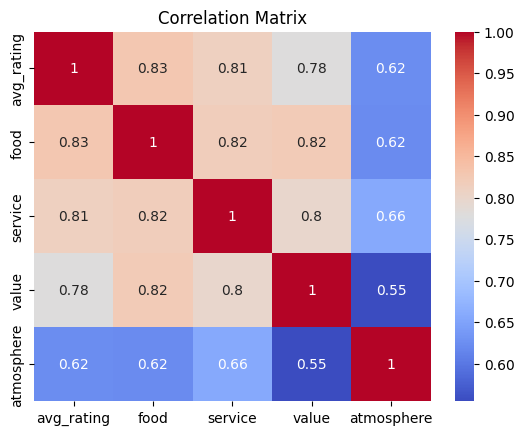

In [42]:
correlation_matrix = df[['avg_rating', 'food', 'service', 'value','atmosphere']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

# Based on the correlation matrix:

## Columns food, service, value are highly correlated to the target variable - and as such are dropped

## Even though the column atmosphere is not highly correlated, we found it's based on users rating, which describe outcome of high ratings, not predictor for a new establishment.

In [43]:
columns_to_drop = [
    'food', 'service', 'value', 'atmosphere'
]
df = df.drop(columns=columns_to_drop,)
df.shape

(559169, 28)

## Check Null values

In [44]:
df.isnull().sum()

restaurant_link                 0
restaurant_name                 0
original_location               0
country                         0
region                      22916
province                   162102
city                            0
address                         0
latitude                     1558
longitude                    1558
claimed                       946
top_tags                      437
price_level                  5906
price_range                369118
meals                      154065
cuisines                    24854
special_diets              236770
features                   357716
vegetarian_friendly             0
vegan_options                   0
gluten_free                     0
original_open_hours        163481
open_days_per_week         163481
open_hours_per_week        163481
working_shifts_per_week    163481
avg_rating                     79
default_language                0
keywords                   461834
dtype: int64

# Based on NULL check:

## Price_range is more than 60% NULL and we can extract the same information from the column price_level which is approximately 1% NULL

## Features column is more than 60% NULL and often overlap with existing cuisine/meal types.

In [45]:
columns_to_drop = [
    'price_range','features'
]
df = df.drop(columns=columns_to_drop,)
df.shape

(559169, 26)

# Drop overlap features that cause redundant information:

## Geospatial Granularity
We prioritized City and Country to maintain a manageable number of features while avoiding overfitting to specific addresses.

* latitude, longitude: GPS coordinates provide too much precision for a general rating model and can lead to overfitting on specific street corners.
* address, original_location: High-cardinality text data that is difficult to encode and mostly unique to each row.
* region, province: Redundant with city and country. Using too many levels of geographic hierarchy introduces multicollinearity.

## Redundancy & Multicollinearity

*   **`top_tags`**: Redundant information. Most keywords found here (e.g., "Italian", "Vegetarian") are already extracted into the `cuisines` or dietary binary columns.
*   **`special_diets`**: The specific dietary needs are already represented by more precise binary features: `vegetarian_friendly`, `vegan_options`, and `gluten_free`.
*   **`original_open_hours`**: Raw text data that was processed into structured features like `open_hours_per_week` and `working_shifts_per_week`.

## Irrelevant Metadata & Unique Identifiers
*These features do not provide any generalizable predictive power.*

*   **`restaurant_name`**: A unique identifier. While a name might carry brand weight, it does not provide a generalizable pattern for the model to learn.
*   **`restaurant_link`**: Metadata used for data scraping and web navigation, irrelevant to statistical modeling.

## Unstructured/Low-Variance Data
 * keywords: This column often contain sparse, unstructured text or descriptions that require heavy NLP processing and often overlap with existing cuisine/meal types.

In [46]:
# Define the list of columns to drop
columns_to_drop = [
    'keywords', 'special_diets',
    'latitude', 'longitude', 'original_location', 'region',
    'province', 'address', 'restaurant_name', 'original_open_hours',
    'top_tags', 'restaurant_link'
]


df = df.drop(columns=columns_to_drop)
df.shape




(559169, 14)

In [47]:
df.columns

Index(['country', 'city', 'claimed', 'price_level', 'meals', 'cuisines',
       'vegetarian_friendly', 'vegan_options', 'gluten_free',
       'open_days_per_week', 'open_hours_per_week', 'working_shifts_per_week',
       'avg_rating', 'default_language'],
      dtype='str')

## Converting Y,N Values for ['vegetarian_friendly', 'vegan_options', 'gluten_free'] to 0,1

In [48]:
#Check if there are NaN values
df[['vegetarian_friendly', 'vegan_options', 'gluten_free']].value_counts(dropna=False).reset_index()

,vegetarian_friendly,vegan_options,gluten_free,count
0,N,N,N,237938
1,Y,N,N,144580
2,Y,Y,Y,78857
3,Y,Y,N,50849
4,Y,N,Y,33365
5,N,N,Y,9732
6,N,Y,N,3095
7,N,Y,Y,753


In [49]:
# Define the columns to convert
binary_cols = ['vegetarian_friendly', 'vegan_options', 'gluten_free']

# Map 'N' to 0 and 'Y' to 1
# We apply the change directly to the dataframe
df[binary_cols] = df[binary_cols].replace({'N': 0, 'Y': 1})

# Verification: Display the first few rows and value counts to confirm the change
print("Conversion complete. New values:")
print(df[binary_cols].value_counts().reset_index())

# Check data types to ensure they are now numeric
print("\nNew column types:")
print(df[binary_cols].dtypes)

Conversion complete. New values:
   vegetarian_friendly  vegan_options  gluten_free   count
0                    0              0            0  237938
1                    1              0            0  144580
2                    1              1            1   78857
3                    1              1            0   50849
4                    1              0            1   33365
5                    0              0            1    9732
6                    0              1            0    3095
7                    0              1            1     753

New column types:
vegetarian_friendly    object
vegan_options          object
gluten_free            object
dtype: object


## Claimed - transforming to binary values

In [50]:
df["claimed"] = df["claimed"].map({
    "Unclaimed": 0,
    "Claimed": 1
})

In [51]:
print("NULL values in claimed:" ,df.claimed.isnull().sum())
print("Non-NULL values in claimed:" ,df.claimed.value_counts())

NULL values in claimed: 946
Non-NULL values in claimed: claimed
1.0    358494
0.0    199729
Name: count, dtype: int64


## Price level - transforming to ordinal


In [52]:
# Mapping price labels while preserving original NaNs
price_map = {
    '€': 1,
    '€€-€€€': 2,
    '€€€€': 3
}

# Map only the existing strings; values not in the map (like NaN) will remain NaN
df['price_level'] = df['price_level'].map(price_map)

print("Price Level conversion complete. Unique values:", df['price_level'].unique())

Price Level conversion complete. Unique values: [ 1.  2.  3. nan]


# Check default_language column values

In [53]:
df.default_language.value_counts()

default_language
English          487692
All languages     71477
Name: count, dtype: int64

# Handling default_language values:

## all languages = 1

## English = 0

In [54]:
df["default_language"] = df["default_language"].map({
    "English": 0,
    "All languages": 1
})

## meals

In [55]:
# Split and explode into individual values
unique_meals = df['meals'].dropna().str.split(', ').explode()

# Get unique categories
unique_categories = unique_meals.unique()

print(f"Number of unique meal categories: {len(unique_categories)}")
print(unique_categories)

Number of unique meal categories: 6
<StringArray>
['Lunch', 'Dinner', 'Drinks', 'After-hours', 'Brunch', 'Breakfast']
Length: 6, dtype: str


In [56]:
# Create NA indicator BEFORE filling
df['NA_meals'] = df['meals'].isna().astype(int)

# Replace NaN with empty string so get_dummies works cleanly
meals_dummies = df['meals'].fillna('').str.get_dummies(sep=', ')
# Merge back
df = pd.concat([df, meals_dummies], axis=1)

# Drop original column
df = df.drop(columns=['meals'])

df.head()

,country,city,claimed,price_level,cuisines,vegetarian_friendly,vegan_options,gluten_free,open_days_per_week,open_hours_per_week,working_shifts_per_week,avg_rating,default_language,NA_meals,After-hours,Breakfast,Brunch,Dinner,Drinks,Lunch
0,France,Saint-Jouvent,1.0,1.0,French,0,0,0,NaN,NaN,NaN,4.0,0,0,0,0,0,1,0,1
3,France,Lacelle,1.0,1.0,French,0,0,0,NaN,NaN,NaN,4.0,0,0,0,0,0,1,0,1
5,France,Le Crozet,1.0,2.0,French,0,0,0,7.0,53.5,12.0,4.5,1,0,0,0,0,1,1,1
6,France,Saint-Denis,1.0,2.0,"French, European",0,0,0,5.0,30.0,10.0,4.5,0,0,0,0,0,1,0,1
7,France,Saint-Denis,1.0,2.0,"French, European",1,0,0,6.0,24.0,6.0,4.5,0,1,0,0,0,0,0,0


## causins

In [57]:
# Split and explode into individual values
unique_cuisines = df['cuisines'].dropna().str.split(', ').explode()

# Get unique categories
unique_categories = unique_cuisines.unique()

print(f"Number of unique cuisines categories: {len(unique_categories)}")
print(unique_categories)

Number of unique cuisines categories: 155
<StringArray>
[          'French',         'European',             'Cafe',
             'Deli',     'Contemporary',        'Gastropub',
         'Wine Bar',        'Fast food',    'International',
          'Italian',
 ...
  'Medicinal foods',          'Latvian',          'Kaiseki',
   'Kyushu cuisine',          'Lombard', 'Hokkaido cuisine',
         'Bahamian',         'Nigerian',     'Puerto Rican',
    'Kyoto cuisine']
Length: 155, dtype: str


In [58]:
cuisines_counts = unique_cuisines.value_counts()

print(cuisines_counts)

cuisines
Italian           152602
European          147873
Mediterranean     136404
Pizza              69973
French             69333
                   ...  
Costa Rican            4
Nigerian               4
Kyushu cuisine         3
Kappo                  2
Bahamian               1
Name: count, Length: 155, dtype: int64


In [ ]:
#creating NA indicator for cuisines
df['NA_cuisines'] = df['cuisines'].isna().astype(int)

#Defining grouping function
def map_cuisine(cuisine):
    cuisine = cuisine.lower()

    if cuisine in ['italian', 'pizza', 'sicilian', 'tuscan', 'southern-italian',
                   'northern-italian', 'central-italian', 'neapolitan']:
        return 'Italian'

    elif cuisine in ['french', 'spanish', 'british', 'german', 'dutch',
                     'belgian', 'austrian', 'scandinavian', 'polish',
                     'swedish', 'danish', 'czech']:
        return 'European'

    elif cuisine in ['greek', 'turkish', 'mediterranean', 'lebanese', 'israeli']:
        return 'Mediterranean'

    elif cuisine in ['chinese', 'japanese', 'sushi', 'korean', 'thai', 'vietnamese',
                     'indian', 'pakistani', 'bangladeshi', 'indonesian']:
        return 'Asian'

    elif cuisine in ['american', 'fast food', 'diner', 'steakhouse']:
        return 'American'

    elif cuisine in ['mexican', 'brazilian', 'argentinian', 'peruvian',
                     'caribbean']:
        return 'Latin American'

    elif cuisine in ['moroccan', 'ethiopian', 'egyptian', 'african']:
        return 'African & Middle Eastern'

    elif cuisine in ['cafe', 'bar', 'pub', 'wine bar', 'gastropub']:
        return 'Dining Style'

    elif cuisine in ['seafood', 'barbecue', 'grill', 'healthy']:
        return 'Specialty'

    else:
        return 'Other'

In [60]:
# Split → map → deduplicate → join back
df['cuisines_grouped'] = (
    df['cuisines']
    .fillna('')
    .apply(lambda x: ', '.join(
        set(map(map_cuisine, x.split(', '))) if x else []
    ))
)

👉 This ensures:

multiple cuisines per row → multiple grouped categories
no duplicates like "Italian, Italian"

In [61]:
cuisine_dummies = df['cuisines_grouped'].str.get_dummies(sep=', ')

In [62]:
#Merge back and clean
df = pd.concat([df, cuisine_dummies], axis=1)

df = df.drop(columns=['cuisines', 'cuisines_grouped'])

In [64]:
cuisine_dummies.sum().sort_values(ascending=False)

Other                       252092
European                    223105
Italian                     162825
Mediterranean               144970
Dining Style                127965
Specialty                   114698
American                     54409
Asian                        47547
Latin American                7644
African & Middle Eastern      2579
dtype: int64